[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/diogoflim/AM/blob/main/6_Perceptron.ipynb)


# Introdução ao Aprendizado de Máquina

**Professor: Diogo Ferreira de Lima Silva (TEP)**

**PPGEP - UFF**


Este notebook foi criado é com base no excelente livro texto:

- Raschka, S., Liu, Y. H., Mirjalili, V., & Dzhulgakov, D. (2022). Machine Learning with PyTorch and Scikit-Learn: Develop machine learning and deep learning models with Python. Packt Publishing Ltd.

- Veja também o código do capítulo 2: https://github.com/rasbt/machine-learning-book



In [24]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import Button, VBox, Output
from matplotlib.colors import ListedColormap
%matplotlib inline

## Classe para o Perceptron

In [25]:
class Perceptron:
    # Construtor
    def __init__(self, taxa_aprendizado=0.01, n_iter=50, random_state=1):
        self.taxa_aprendizado = taxa_aprendizado
        self.n_iter = n_iter
        self.random_state = random_state

    # Fit aos dados de treinamento
    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1]) # Inicializando o vetor de pesos
        self.b_ = np.float64(0.) # Inicializado o bias
        

        self.erros_ = [] # Lista vazia que receberá uma contagem de erros em uma passagem pelo Conjunto de Treinamento
        self.historico_pesos_ = [(self.w_.copy(), self.b_)]  # salvar pesos iniciais


        for i in range(self.n_iter):
            erros = 0
            for xi, yi in zip(X, y):
                update = self.taxa_aprendizado * (yi - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update
                erros += int(update != 0.0) # se errou, soma 1
            self.erros_.append(erros)
            self.historico_pesos_.append((self.w_.copy(), self.b_))  # salvar após cada época
        return self

    def net_input(self, X):
        # zi = xi1*w1 + xi2*w2 + ... + xip*wp + b
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, 0)

Vamos criar um conjunto de dados aleatório com 2 centros distintos.

In [26]:
from sklearn.datasets import make_blobs

# Gerando os dados
X, y = make_blobs(n_samples=200, centers=2, n_features=2, cluster_std=2.0, random_state=42)

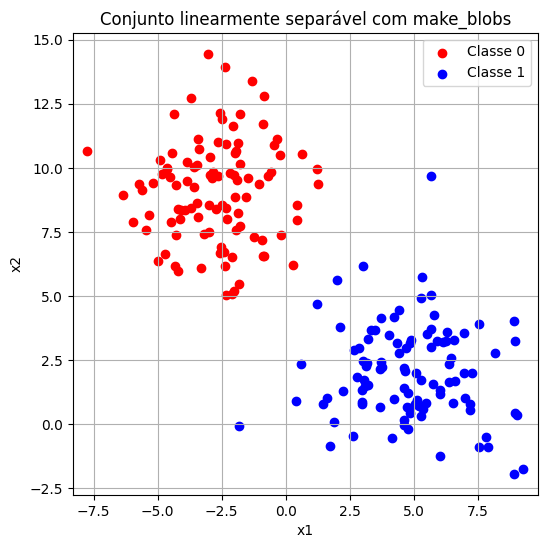

In [27]:
# Visualização
plt.figure(figsize=(6, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Classe 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Classe 1')
plt.title("Conjunto linearmente separável com make_blobs")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Text(0, 0.5, 'Número de updates na passagem (erros)')

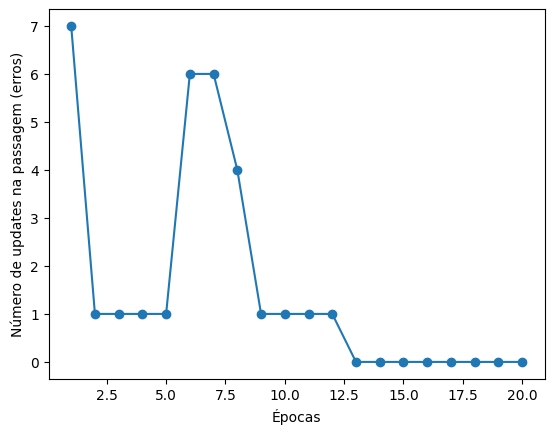

In [29]:
ppn = Perceptron(taxa_aprendizado=0.1, n_iter=20)

ppn.fit(X_train, y_train)

plt.plot(range(1, len(ppn.erros_) + 1), ppn.erros_, marker='o')
plt.xlabel('Épocas')
plt.ylabel('Número de updates na passagem (erros)')

In [30]:
# Função para plotar regiões de decisão. Veja em Raschka et al. (2022)


def plot_decision_regions(ax, X, y, classifier, resolution=0.02):
    markers = ('o', 's')
    colors = ('red', 'blue')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)

    ax.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    ax.set_xlim(xx1.min(), xx1.max())
    ax.set_ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        ax.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                   alpha=0.8, c=colors[idx],
                   marker=markers[idx], label=f'Classe {cl}',
                   edgecolor='black')


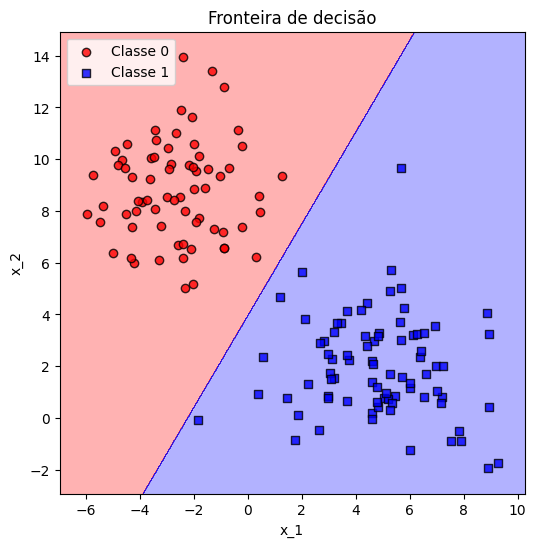

In [31]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_decision_regions(ax, X_train, y_train, classifier=ppn)
ax.set_title("Fronteira de decisão")
plt.xlabel('x_1')
plt.ylabel('x_2')
ax.legend(loc='upper left')
plt.show()


## Gráfico Iterativo

In [32]:
# Vamos criar uma classe simples para usar pesos antigos
class DummyPerceptron:
    def __init__(self, w, b):
        self.w_ = w
        self.b_ = b
    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_
    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, 0)


In [33]:
# Importação dos widgets e do display interativo

output = Output()  # Área onde o gráfico será exibido
botao = Button(description="Próxima época")  # Cria um botão com o texto "Próxima época"
epoca_atual = {'index': 0}  # Dicionário mutável para manter o controle da época atual

In [34]:
# Função chamada toda vez que o botão for clicado
@botao.on_click

def on_button_clicked(b):
    with output:  # Tudo dentro desse bloco será exibido no widget 'output'
        output.clear_output(wait=True)  # Limpa a saída anterior para exibir o novo gráfico
        fig, ax = plt.subplots(figsize=(6, 6))  # Cria uma nova figura e eixos do matplotlib
        
        # Recupera os pesos e bias salvos para a época atual
        i = epoca_atual['index']
        w, b = ppn.historico_pesos_[i]
        
        # Cria um modelo "congelado" com os pesos e bias dessa época
        dummy = DummyPerceptron(w, b)
        
        # Plota a região de decisão para essa época
        plot_decision_regions(ax, X_train, y_train, classifier=dummy)
        ax.set_title(f'Época {i}')  # Título indicando qual época está sendo exibida
        ax.legend(loc='upper right')  # Legenda no canto superior direito

        # Exibe os valores de w e b no canto inferior esquerdo do gráfico
        ax.text(0.02, 0.02,
                f"w = [{w[0]:.2f}, {w[1]:.2f}]\nb = {b:.2f}",
                transform=ax.transAxes,
                fontsize=10,
                verticalalignment='bottom',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

        
        
        plt.show()  # Exibe o gráfico
        
        # Atualiza o índice da época para a próxima (com volta ao início)
        epoca_atual['index'] = (i + 1) % len(ppn.historico_pesos_)



In [35]:
# Exibe o botão e a área de gráficos em um layout vertical
VBox([botao, output])


In [36]:
y_pred = ppn.predict(X_test)
print(f'Número de erros: {(y_test != y_pred).sum()}')

Número de erros: 0


# Exercício

Aplique uma normalização aos dados de treinamento e repita o procedimento acima.

## Utilizando o Scikit Learn

In [37]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [38]:
from sklearn.linear_model import Perceptron

ppn = Perceptron(eta0=0.1, random_state=1)
ppn.fit(X_train_std, y_train)

Perceptron(eta0=0.1, random_state=1)

In [39]:
y_pred = ppn.predict(X_test_std)
print('Exemplos errados: %d' % (y_test != y_pred).sum())

Exemplos errados: 0


# Problema com múltiplas classes

Vamos criar um conjunto de dados mais complexo, envolvendo várias classes.

In [40]:
X, y = make_blobs(n_samples=200, centers=4, n_features=2, cluster_std=2.0, random_state=42)

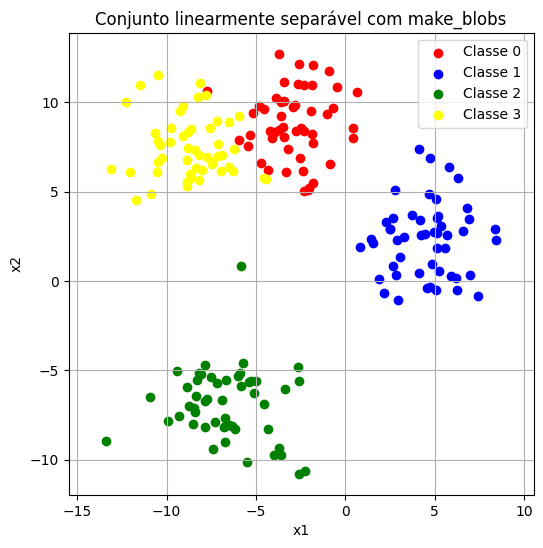

In [41]:
# Visualização
plt.figure(figsize=(6, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Classe 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Classe 1')
plt.scatter(X[y == 2][:, 0], X[y == 2][:, 1], color='green', label='Classe 2')
plt.scatter(X[y == 3][:, 0], X[y == 3][:, 1], color='yellow', label='Classe 3')
plt.title("Conjunto linearmente separável com make_blobs")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [43]:
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

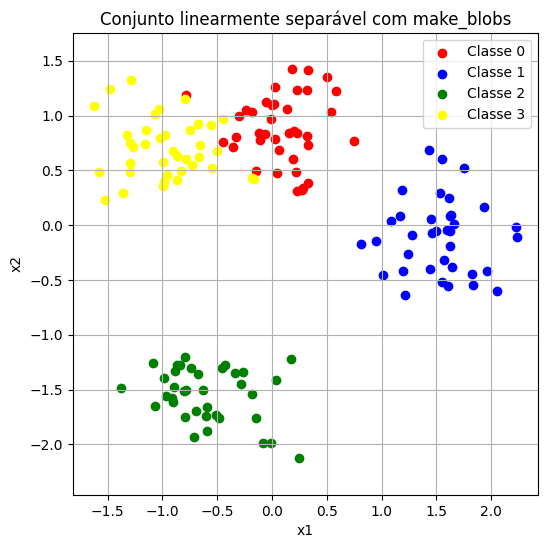

In [44]:
# Visualização
plt.figure(figsize=(6, 6))
plt.scatter(X_train_std[y_train == 0][:, 0], X_train_std[y_train == 0][:, 1], color='red', label='Classe 0')
plt.scatter(X_train_std[y_train == 1][:, 0], X_train_std[y_train == 1][:, 1], color='blue', label='Classe 1')
plt.scatter(X_train_std[y_train == 2][:, 0], X_train_std[y_train == 2][:, 1], color='green', label='Classe 2')
plt.scatter(X_train_std[y_train == 3][:, 0], X_train_std[y_train == 3][:, 1], color='yellow', label='Classe 3')
plt.title("Conjunto linearmente separável com make_blobs")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()

In [45]:
ppn = Perceptron(eta0=0.1, random_state=1)
ppn.fit(X_train_std, y_train)

Perceptron(eta0=0.1, random_state=1)

In [46]:
y_pred = ppn.predict(X_test_std)
print('Exemplos errados: %d' % (y_test != y_pred).sum())

Exemplos errados: 2


## **Como assim? Funcionou?**

Vimos na aula que o `Perceptron` é um procedimento para problemas de duas classes! Foi assim que programamos a nossa classe.

Por que a função do sklearn funcionou para um problema com 4 classes?

### One-vs-Rest

O `Perceptron` do `scikit-learn` utiliza automaticamente uma estratégia chamada **One-vs-Rest (OvR)** para lidar com problemas de múltiplas classes.

Essa estratégia cria **um classificador binário para cada classe**, onde cada modelo aprende a distinguir:

> “Esta classe” vs “Todas as outras”

Ou seja, com 4 classes (0, 1, 2 e 3), ele cria 4 classificadores binários independentes. 

Cada classificador calcula um **score** para a entrada (o valor do modelo linear: `wᵗx + b`), e a classe final é aquela com o **maior score**.

Mesmo que o algoritmo de base seja binário, essa estrutura permite lidar com quantas classes forem necessárias!

O score $z$ indica a distância relativa ao hiperplano de cada classificador.

Quanto mais positivo o score, mais longe (e confiantemente) o exemplo está do lado “positivo” do hiperplano para aquela classe.

Então escolhe-se a classe onde, ao analisar o hiperplano, ficamos mais distantes e confiante para o exemplo expecífico.